# Lab | Hypothesis Testing

**Objective**

Welcome to the Hypothesis Testing Lab, where we embark on an enlightening journey through the realm of statistical decision-making! In this laboratory, we delve into various scenarios, applying the powerful tools of hypothesis testing to scrutinize and interpret data.

From testing the mean of a single sample (One Sample T-Test), to investigating differences between independent groups (Two Sample T-Test), and exploring relationships within dependent samples (Paired Sample T-Test), our exploration knows no bounds. Furthermore, we'll venture into the realm of Analysis of Variance (ANOVA), unraveling the complexities of comparing means across multiple groups.

So, grab your statistical tools, prepare your hypotheses, and let's embark on this fascinating journey of exploration and discovery in the world of hypothesis testing!

**Challenge 1**

In this challenge, we will be working with pokemon data. The data can be found here:

- https://raw.githubusercontent.com/data-bootcamp-v4/data/main/pokemon.csv

In [21]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns      
from scipy import stats



In [4]:
pokemon = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/pokemon.csv")
pokemon

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...
795,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True


- We posit that Pokemons of type Dragon have, on average, more HP stats than Grass. Choose the propper test and, with 5% significance, comment your findings.

In [ ]:
pokemon


In [6]:
dragon_hp = pokemon[pokemon['Type 1'] == 'Dragon']['HP']
grass_hp = pokemon[pokemon['Type 1'] == 'Grass']['HP']

print(f"Sample size - Dragon: {len(dragon_hp)}")
print(f"Sample size - Grass: {len(grass_hp)}")
print(f"Mean HP - Dragon: {dragon_hp.mean():.2f}")
print(f"Mean HP - Grass: {grass_hp.mean():.2f}")

Sample size - Dragon: 32
Sample size - Grass: 70
Mean HP - Dragon: 83.31
Mean HP - Grass: 67.27


In [9]:
# 2. Equality of Variance (Levene's Test)
stat_lev, p_lev = stats.levene(dragon_hp, grass_hp)
print(f"Levene's Test p-value: {p_lev:.4f}")

Levene's Test p-value: 0.1748


In [11]:
# 3. Independent T-Test
t_stat, p_value = stats.ttest_ind(dragon_hp, grass_hp, equal_var=(p_lev > 0.05))
print(f"T-test Statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-test Statistic: 3.5904
P-value: 0.0005


As p<0.05, we reject the null hypothesis. There is statistically significant evidence to conclude that Dragon-type Pokémon have, on average, higher HP stats than Grass-type Pokémon

- We posit that Legendary Pokemons have different stats (HP, Attack, Defense, Sp.Atk, Sp.Def, Speed) when comparing with Non-Legendary. Choose the propper test and, with 5% significance, comment your findings.


In [13]:
stats_list = ['HP', 'Attack', 'Defense', 'Sp_Atk', 'Sp_Def', 'Speed']

In [14]:
pokemon.columns = [c.replace(' ', '_').replace('.', '') for c in pokemon.columns]

In [15]:
legendary = pokemon[pokemon['Legendary'] == True]
non_legendary = pokemon[pokemon['Legendary'] == False]

In [16]:
results = []

for stat in stats_list:
    # 1. Levene's test for equality of variance
    _, p_lev = stats.levene(legendary[stat], non_legendary[stat])
    
    # 2. Independent T-test 
    t_stat, p_val = stats.ttest_ind(legendary[stat], non_legendary[stat], equal_var=(p_lev > 0.05))
    
    results.append({
        'Stat': stat,
        'Legendary_Mean': round(legendary[stat].mean(), 2),
        'Non_Legendary_Mean': round(non_legendary[stat].mean(), 2),
        'P_Value': round(p_val, 10),
        'Significant': p_val < 0.05
    })


results_df = pd.DataFrame(results)
results_df

,Stat,Legendary_Mean,Non_Legendary_Mean,P_Value,Significant
0,HP,92.74,67.18,0.0,True
1,Attack,116.68,75.67,0.0,True
2,Defense,99.66,71.56,0.0,True
3,Sp_Atk,122.18,68.45,0.0,True
4,Sp_Def,105.94,68.89,0.0,True
5,Speed,100.18,65.46,0.0,True


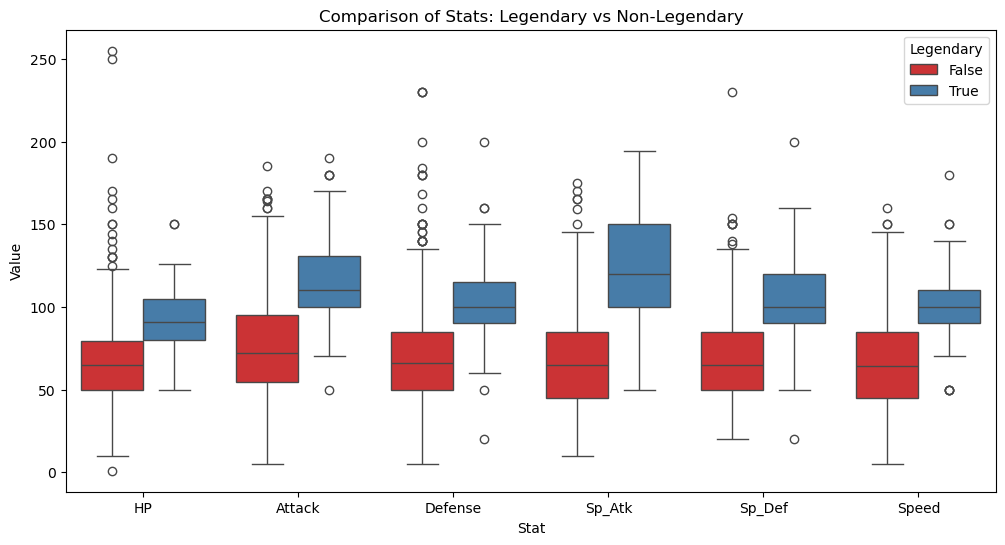

In [22]:
melted_pokemon = pokemon.melt(id_vars='Legendary', value_vars=stats_list, var_name='Stat', value_name='Value')

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted_pokemon, x='Stat', y='Value', hue='Legendary', palette='Set1')
plt.title('Comparison of Stats: Legendary vs Non-Legendary')
plt.show()

The statistical analysis through independent T-tests confirms that Legendary Pokemon are significantly different and superior across all base stats compared to Non-Legendary Pokemon.

**Challenge 2**

In this challenge, we will be working with california-housing data. The data can be found here:
- https://raw.githubusercontent.com/data-bootcamp-v4/data/main/california_housing.csv

In [26]:
housing = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/california_housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


**We posit that houses close to either a school or a hospital are more expensive.**

- School coordinates (-118, 34)
- Hospital coordinates (-122, 37)

We consider a house (neighborhood) to be close to a school or hospital if the distance is lower than 0.50.

Hint:
- Write a function to calculate euclidean distance from each house (neighborhood) to the school and to the hospital.
- Divide your dataset into houses close and far from either a hospital or school.
- Choose the propper test and, with 5% significance, comment your findings.
 

In [24]:
school_coord = (-118, 34)
hospital_coord = (-122, 37)

def calculate_distance(row, target_coord):
    # Euclidean distance formula: sqrt((x2-x1)^2 + (y2-y1)^2)
    return np.sqrt((row['longitude'] - target_coord[0])**2 + (row['latitude'] - target_coord[1])**2)

In [27]:
housing['dist_school'] = housing.apply(lambda x: calculate_distance(x, school_coord), axis=1)
housing['dist_hospital'] = housing.apply(lambda x: calculate_distance(x, hospital_coord), axis=1)

In [28]:
housing['is_close'] = (housing['dist_school'] < 0.5) | (housing['dist_hospital'] < 0.5)

In [29]:
close_houses = housing[housing['is_close'] == True]['median_house_value']
far_houses = housing[housing['is_close'] == False]['median_house_value']

print(f"Neighborhoods close to amenities: {len(close_houses)}")
print(f"Neighborhoods far from amenities: {len(far_houses)}")

Neighborhoods close to amenities: 6829
Neighborhoods far from amenities: 10171


In [30]:
# 1. Levene's Test for equality of variance
stat_lev, p_lev = stats.levene(close_houses, far_houses)
print(f"Levene's Test P-value: {p_lev:.4f}")

Levene's Test P-value: 0.0208


In [31]:
# 2. Independent T-test
# We use Welch's T-test (equal_var=False) because Levene's p-value is likely < 0.05
t_stat, p_val = stats.ttest_ind(close_houses, far_houses, equal_var=(p_lev > 0.05))

print(f"T-test Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

T-test Statistic: 37.9923
P-value: 0.0000


As p<0.5, we reject the H0, and we accept that neighborhoods close to a school/hospital have a significantly different (higher) median house value.

C:\Users\lugon\AppData\Local\Temp\ipykernel_24652\3485528224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_close', y='median_house_value', data=housing, palette='magma')


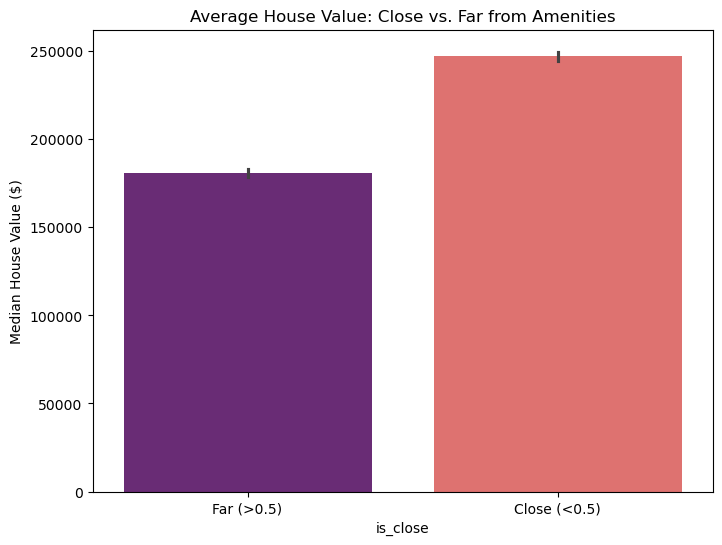

In [32]:
#visualization 
plt.figure(figsize=(8, 6))
sns.barplot(x='is_close', y='median_house_value', data=housing, palette='magma')
plt.title('Average House Value: Close vs. Far from Amenities')
plt.xticks([0, 1], ['Far (>0.5)', 'Close (<0.5)'])
plt.ylabel('Median House Value ($)')
plt.show()